Mutual Fund Performance Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [6]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])


In [7]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [9]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [10]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[us]
 1   index_name   8050 non-null   str           
 2   close_value  8050 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 271.9 KB


In [11]:
benchmark.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [12]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


Dailyy Return Analysis

In [17]:
# Sort by scheme and date
nav = nav.sort_values(["amfi_code", "date"])

In [16]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [18]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [19]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [20]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


CAGR Analysis

In [21]:
cagr_data = nav.groupby("amfi_code").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
).reset_index()

cagr_data.head()

,amfi_code,start_date,end_date,start_nav,end_nav
0,100016,2022-01-03,2026-05-29,520.4608,583.6113
1,100025,2022-01-03,2026-05-29,26.3169,31.8843
2,100033,2022-01-03,2026-05-29,107.3758,342.0072
3,101206,2022-01-03,2026-05-29,305.0996,773.2939
4,101207,2022-01-03,2026-05-29,38.5736,53.9836


In [22]:
cagr_data["years"] = (
    (cagr_data["end_date"] - cagr_data["start_date"]).dt.days
) / 365.25

cagr_data.head()


,amfi_code,start_date,end_date,start_nav,end_nav,years
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726


In [23]:
cagr_data["cagr"] = (
    (cagr_data["end_nav"] / cagr_data["start_nav"])
    ** (1 / cagr_data["years"])
) - 1

cagr_data.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388


In [24]:
cagr_data["cagr_percent"] = cagr_data["cagr"] * 100

cagr_data.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371,2.637074
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582,4.458210
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384,23.538361
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388,7.938765


In [25]:
cagr_data.sort_values(
    by="cagr_percent",
    ascending=False
).head(10)

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent
25,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406
21,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536
39,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440
36,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523
34,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108
30,120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153
38,149323,2022-01-03,2026-05-29,78.4622,245.3651,4.399726,0.295811,29.581087
16,119094,2022-01-03,2026-05-29,68.3023,203.8581,4.399726,0.282144,28.214417
19,119551,2022-01-03,2026-05-29,54.3856,149.3216,4.399726,0.258047,25.804686


Business Insights
- CAGR measures the average annual growth rate of each mutual fund.
- Higher CAGR indicates better long-term performance.
- Investors generally prefer funds with consistently higher CAGR over multiple years.

In [26]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


One-Year CAGR

In [27]:
# Latest date in the dataset
latest_date = nav["date"].max()

# Date one year before
one_year_date = latest_date - pd.DateOffset(years=1)

# Latest NAV for each fund
latest_nav = (
    nav.groupby("amfi_code")
    .last()[["nav"]]
    .rename(columns={"nav": "latest_nav"})
)

# NAV one year ago
one_year_nav = (
    nav[nav["date"] >= one_year_date]
    .groupby("amfi_code")
    .first()[["nav"]]
    .rename(columns={"nav": "one_year_nav"})
)

# Merge
cagr_1yr = latest_nav.join(one_year_nav)

# Calculate CAGR
cagr_1yr["CAGR_1Y"] = (
    (cagr_1yr["latest_nav"] / cagr_1yr["one_year_nav"]) ** (1/1)
) - 1

cagr_1yr.head()

,latest_nav,one_year_nav,CAGR_1Y
amfi_code,,,
100016,583.6113,596.8877,-0.022243
100025,31.8843,30.7452,0.037050
100033,342.0072,223.1951,0.532324
101206,773.2939,522.7639,0.479241
101207,53.9836,71.0180,-0.239860


Three-Year CAGR

In [28]:
# Date three years before the latest date
three_year_date = latest_date - pd.DateOffset(years=3)

# NAV three years ago
three_year_nav = (
    nav[nav["date"] >= three_year_date]
    .groupby("amfi_code")
    .first()[["nav"]]
    .rename(columns={"nav": "three_year_nav"})
)

# Merge
cagr_3yr = latest_nav.join(three_year_nav)

# Calculate 3-Year CAGR
cagr_3yr["CAGR_3Y"] = (
    (cagr_3yr["latest_nav"] / cagr_3yr["three_year_nav"]) ** (1/3)
) - 1

cagr_3yr.head()

,latest_nav,three_year_nav,CAGR_3Y
amfi_code,,,
100016,583.6113,561.5519,0.012926
100025,31.8843,28.4135,0.039164
100033,342.0072,147.2155,0.324425
101206,773.2939,360.4971,0.289677
101207,53.9836,61.3081,-0.041524


Five-Year CAGR

In [29]:
five_year_date = latest_date - pd.DateOffset(years=5)

five_year_nav = (
    nav[nav["date"] >= five_year_date]
    .groupby("amfi_code")
    .first()[["nav"]]
    .rename(columns={"nav": "five_year_nav"})
)

cagr_5yr = latest_nav.join(five_year_nav)

cagr_5yr["CAGR_5Y"] = (
    (cagr_5yr["latest_nav"] / cagr_5yr["five_year_nav"]) ** (1/5)
) - 1

cagr_5yr.head()

,latest_nav,five_year_nav,CAGR_5Y
amfi_code,,,
100016,583.6113,520.4608,0.023168
100025,31.8843,26.3169,0.039127
100033,342.0072,107.3758,0.260741
101206,773.2939,305.0996,0.204427
101207,53.9836,38.5736,0.069533


In [30]:
cagr_table = (
    cagr_1yr[["CAGR_1Y"]]
    .join(cagr_3yr[["CAGR_3Y"]])
    .join(cagr_5yr[["CAGR_5Y"]])
)

cagr_table = cagr_table.reset_index()

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


Business Insight
- CAGR provides the annualized growth rate of mutual funds over different investment horizons.
- Higher CAGR indicates stronger long-term performance.
- The available dataset supports reliable 1-year and 3-year CAGR analysis, while a complete 5-year CAGR requires a longer historical dataset.


Sharp Ratio Analysis

In [31]:
# Annual Risk-Free Rate
risk_free_rate = 0.065

# Daily Risk-Free Rate
daily_rf = risk_free_rate / 252

daily_rf

0.00025793650793650796

In [32]:
sharpe_ratio = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe_ratio["Sharpe_Ratio"] = (
    (sharpe_ratio["mean"] - daily_rf)
    / sharpe_ratio["std"]
) * (252 ** 0.5)

sharpe_ratio.head()

,amfi_code,mean,std,Sharpe_Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [33]:
sharpe_ratio = sharpe_ratio.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_ratio["Rank"] = range(
    1,
    len(sharpe_ratio) + 1
)

sharpe_ratio.head(10)

,amfi_code,mean,std,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448291,1
30,120843,0.001082,0.010008,1.306744,2
36,148569,0.001124,0.011134,1.234930,3
19,119551,0.000917,0.008656,1.208267,4
25,120505,0.001161,0.012152,1.180101,5
38,149323,0.001055,0.011179,1.132122,6
2,100033,0.001080,0.011929,1.093699,7
9,118632,0.000865,0.008913,1.081659,8
3,101206,0.000852,0.009177,1.027213,9
24,120504,0.000843,0.009048,1.026524,10


Business Insight
- Sharpe Ratio measures return earned for each unit of risk.
- Higher Sharpe Ratio indicates better risk-adjusted performance.
- Funds with the highest Sharpe Ratio are generally considered more efficient investments.

Sortino Ratio Analysis

In [34]:
# Keep only negative daily returns
downside_returns = nav.copy()

downside_returns["downside_return"] = downside_returns["daily_return"]

downside_returns.loc[
    downside_returns["downside_return"] > 0,
    "downside_return"
] = 0

downside_returns.head()

,amfi_code,date,nav,daily_return,downside_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,0.000000
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [35]:
sortino_ratio = (
    downside_returns.groupby("amfi_code")
    .agg(
        mean_return=("daily_return", "mean"),
        downside_std=("downside_return", "std")
    )
    .reset_index()
)

sortino_ratio["Sortino_Ratio"] = (
    (sortino_ratio["mean_return"] - daily_rf)
    / sortino_ratio["downside_std"]
) * np.sqrt(252)

sortino_ratio.head()

,amfi_code,mean_return,downside_std,Sortino_Ratio
0,100016,0.000142,0.005163,-0.357702
1,100025,0.000170,0.001382,-1.009643
2,100033,0.001080,0.006632,1.967316
3,101206,0.000852,0.004989,1.889576
4,101207,0.000424,0.009256,0.285576


In [36]:
sortino_ratio = sortino_ratio.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_ratio["Rank"] = range(
    1,
    len(sortino_ratio) + 1
)

sortino_ratio.head(10)

,amfi_code,mean_return,downside_std,Sortino_Ratio,Rank
34,148567,0.001074,0.004962,2.609850,1
30,120843,0.001082,0.005308,2.463887,2
36,148569,0.001124,0.006035,2.278106,3
19,119551,0.000917,0.004662,2.243325,4
25,120505,0.001161,0.006644,2.158384,5
38,149323,0.001055,0.006291,2.011887,6
2,100033,0.001080,0.006632,1.967316,7
9,118632,0.000865,0.004914,1.961986,8
3,101206,0.000852,0.004989,1.889576,9
24,120504,0.000843,0.004947,1.877411,10


Business Insight
- Sortino Ratio evaluates returns considering only downside risk.
- Unlike Sharpe Ratio, it ignores positive volatility.
- Higher Sortino Ratio indicates better protection against losses while delivering returns.

In [37]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


Alpha & Beta Analysis

In [41]:
# Sort benchmark data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate daily benchmark returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [39]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [40]:
benchmark.head()

,date,index_name,close_value
3450,2022-01-03,BSE_SMALLCAP,26554.60
3451,2022-01-04,BSE_SMALLCAP,27079.92
3452,2022-01-05,BSE_SMALLCAP,27313.35
3453,2022-01-06,BSE_SMALLCAP,27377.05
3454,2022-01-07,BSE_SMALLCAP,26316.86


In [42]:
benchmark["index_name"].unique()

<ArrowStringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [43]:
benchmark["index_name"] == "NIFTY100"

3450    False
3451    False
3452    False
3453    False
3454    False
        ...  
3445    False
3446    False
3447    False
3448    False
3449    False
Name: index_name, Length: 8050, dtype: bool

In [45]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [46]:
merged = pd.merge(
    nav,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [47]:
from scipy.stats import linregress

alpha_beta = []

for fund in merged["amfi_code"].unique():

    temp = merged[merged["amfi_code"] == fund].dropna()

    if len(temp) > 10:

        slope, intercept, r_value, p_value, std_err = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": fund,
            "Alpha": intercept * 252,
            "Beta": slope
        })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [48]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


Business Insight
- Beta measures how sensitive a mutual fund is to movements in the NIFTY100 benchmark.
- Alpha measures the fund's excess return compared to the benchmark.
- Funds with positive Alpha have outperformed the benchmark after adjusting for market movements.

Maximum Drawdown Analysis

In [49]:
# Running maximum NAV for each fund
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

# Drawdown calculation
nav["drawdown"] = (nav["nav"] / nav["running_max"]) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [50]:
max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.columns = ["amfi_code", "Maximum_Drawdown"]

max_drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


Business Insight
- Maximum Drawdown measures the largest decline from a previous peak.
- Lower drawdown indicates better downside protection.

Fund Scorecard

In [51]:
# Merge all metrics
scorecard = performance.merge(
    sharpe_ratio[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_drawdown,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14.0,-21.70,14288,1.54,4,Moderate,1.208267,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,14.0,-24.43,1231,0.66,3,Moderate,0.953279,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,25.0,-13.35,19259,1.43,5,Very High,0.945308,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,25.0,-24.78,36061,0.72,4,Very High,-0.057187,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,4.0,-2.30,24101,0.77,5,Low,-0.226575,0.056209,-0.006414,-0.043287


In [52]:
# Ranking

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["Maximum_Drawdown"].rank(ascending=True)

In [53]:
scorecard["Fund_Score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values("Fund_Score")

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.945308,0.303370,-0.023196,-0.287060,1.0,14.0,1.0,21.0,5.0,7.650
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,1.180101,0.292636,0.000549,-0.181885,8.0,5.0,3.0,15.0,16.0,8.100
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,0.949796,0.300579,0.011455,-0.311719,6.0,13.0,2.0,26.5,4.0,9.825
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,1.093699,0.271954,0.005104,-0.162172,10.0,7.0,6.0,17.0,21.0,10.600
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.306744,0.273305,-0.022830,-0.129740,11.0,2.0,5.0,22.0,28.0,10.900
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,...,0.998231,0.260767,-0.066265,-0.209609,15.0,11.0,9.0,17.0,13.0,12.900
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,...,1.132122,0.265986,-0.002523,-0.172481,9.0,6.0,8.0,38.0,19.0,13.400
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.448291,0.269838,0.023684,-0.112657,17.0,1.0,7.0,23.0,33.0,13.500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,1.026524,0.211948,0.016232,-0.125883,20.0,10.0,13.0,12.0,29.0,15.800
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,...,1.234930,0.282704,0.018134,-0.163967,23.0,3.0,4.0,36.5,20.0,15.925


Benchmark Comparison

In [54]:
top5 = scorecard.nsmallest(5, "Fund_Score")["amfi_code"]

comparison = nav[nav["amfi_code"].isin(top5)]

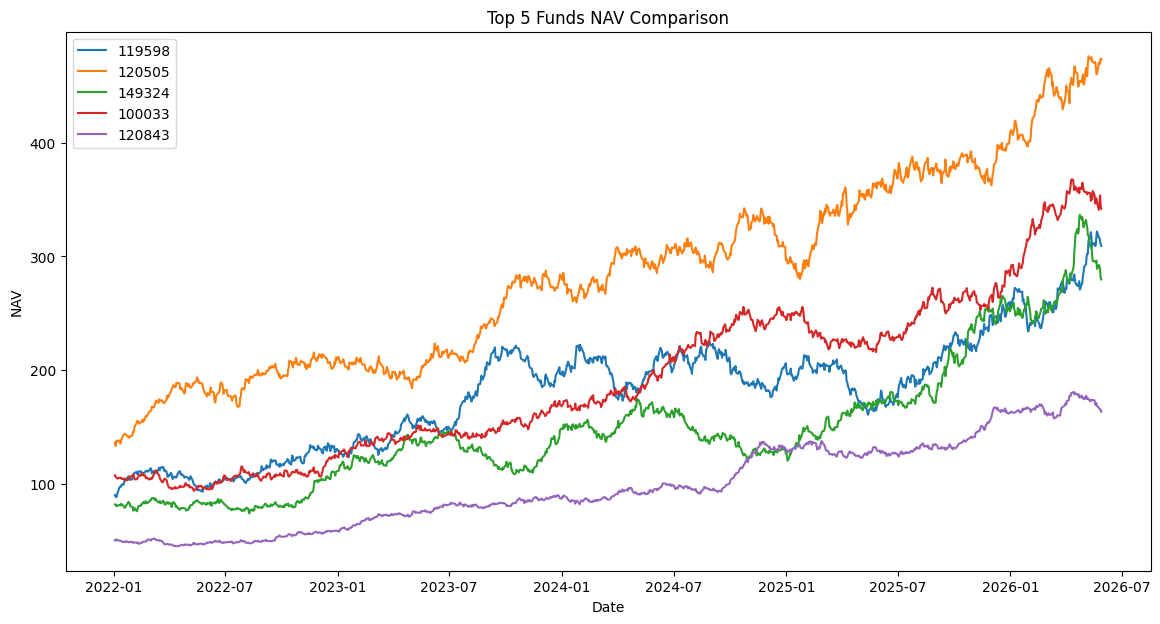

In [55]:
plt.figure(figsize=(14,7))

for fund in top5:
    temp = comparison[comparison["amfi_code"] == fund]
    plt.plot(temp["date"], temp["nav"], label=str(fund))

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.savefig("../charts/benchmark_comparison.png")

plt.show()

# Conclusion

This notebook analyzed the performance of mutual funds using:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

The generated CSV files and charts can be used for further reporting and decision-making.

10. Benchmark Comparison - Top 5 Funds vs NIFTY50 and NIFTY100

In [4]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        if "nav" in file.lower():
            print(os.path.join(root, file))

../data\processed\nav_history_cleaned.csv
../data\raw\02_nav_history.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.columns.tolist())
print(nav.shape)

['amfi_code', 'date', 'nav']
(46000, 3)


In [6]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

print(benchmark.columns.tolist())
print(benchmark.shape)

['date', 'index_name', 'close_value']
(8050, 3)


In [7]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

print("Daily returns recreated successfully!")

Daily returns recreated successfully!


In [8]:
latest_date = nav["date"].max()

print("Latest date:", latest_date)

Latest date: 2026-05-29 00:00:00


In [9]:
three_year_start = latest_date - pd.DateOffset(years=3)

nav_3yr = nav[nav["date"] >= three_year_start].copy()

benchmark_3yr = benchmark[
    benchmark["date"] >= three_year_start
].copy()

print("3-year data prepared!")
print("Start:", three_year_start)
print("End:", latest_date)

3-year data prepared!
Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00


In [10]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"].pct_change()
)

In [11]:
nifty50_3yr = benchmark[
    (benchmark["index_name"] == "NIFTY50") &
    (benchmark["date"] >= three_year_start)
].copy()

nifty100_3yr = benchmark[
    (benchmark["index_name"] == "NIFTY100") &
    (benchmark["date"] >= three_year_start)
].copy()

print("NIFTY50 rows:", len(nifty50_3yr))
print("NIFTY100 rows:", len(nifty100_3yr))

NIFTY50 rows: 785
NIFTY100 rows: 785


In [13]:
print(nav.columns.tolist())
print(nav["amfi_code"].nunique())

['amfi_code', 'date', 'nav', 'daily_return']
40


In [14]:
fund_returns = (
    nav.groupby("amfi_code")["daily_return"]
    .mean()
    .sort_values(ascending=False)
)

top5 = fund_returns.head(5).index.tolist()

print("Top 5 funds:")
print(top5)

Top 5 funds:
[119598, 149324, 120505, 148569, 120843]


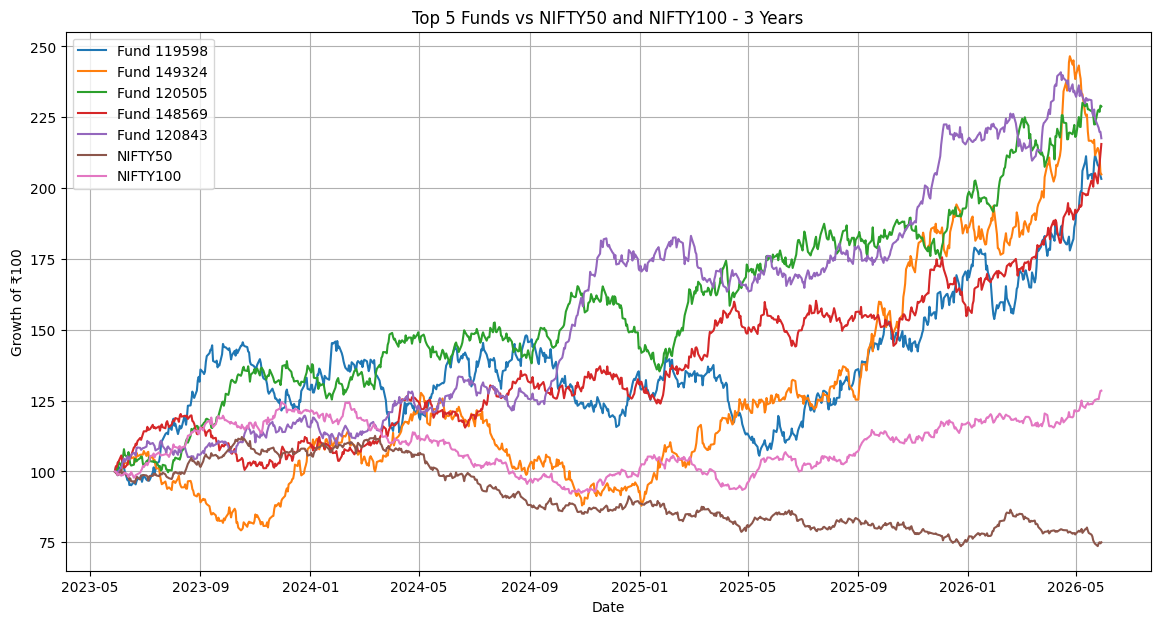

In [15]:
plt.figure(figsize=(14, 7))

for fund in top5:
    temp = nav_3yr[
        nav_3yr["amfi_code"] == fund
    ].copy()

    temp["normalized"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {fund}"
    )

# NIFTY50
nifty50_3yr["normalized"] = (
    nifty50_3yr["close_value"]
    / nifty50_3yr["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50_3yr["date"],
    nifty50_3yr["normalized"],
    label="NIFTY50"
)

# NIFTY100
nifty100_3yr["normalized"] = (
    nifty100_3yr["close_value"]
    / nifty100_3yr["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100_3yr["date"],
    nifty100_3yr["normalized"],
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 and NIFTY100 - 3 Years")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.grid(True)

plt.savefig(
    "../charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Tracking Error

In [16]:
tracking_data = pd.merge(
    nav_3yr[["amfi_code", "date", "daily_return"]],
    nifty100_3yr[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

tracking_error = (
    tracking_data
    .groupby("amfi_code")
    .apply(
        lambda x:
        (x["daily_return"] - x["benchmark_return"]).std()
        * np.sqrt(252)
    )
    .reset_index(name="Tracking_Error")
)

tracking_error.head()

,amfi_code,Tracking_Error
0,100016,0.195345
1,100025,0.133607
2,100033,0.224838
3,101206,0.188852
4,101207,0.292998


In [17]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking error saved successfully!")

Tracking error saved successfully!


In [18]:
tracking_error.head()

,amfi_code,Tracking_Error
0,100016,0.195345
1,100025,0.133607
2,100033,0.224838
3,101206,0.188852
4,101207,0.292998


In [19]:
import os

files_to_check = [
    "../reports/alpha_beta.csv",
    "../reports/fund_scorecard.csv",
    "../charts/benchmark_comparison.png"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✅ FOUND:", file)
    else:
        print("❌ MISSING:", file)

✅ FOUND: ../reports/alpha_beta.csv
❌ MISSING: ../reports/fund_scorecard.csv
✅ FOUND: ../charts/benchmark_comparison.png


In [20]:
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [22]:
alpha_beta = pd.read_csv("../reports/alpha_beta.csv")

print(alpha_beta.head())

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [23]:
rf = 0.065

sharpe_ratio = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe_ratio["Sharpe_Ratio"] = (
    (sharpe_ratio["mean"] * 252 - rf)
    / (sharpe_ratio["std"] * np.sqrt(252))
)

sharpe_ratio = sharpe_ratio[
    ["amfi_code", "Sharpe_Ratio"]
]

sharpe_ratio.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [24]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
    .cummax()
)

nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.columns = [
    "amfi_code",
    "Maximum_Drawdown"
]

max_drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [25]:
scorecard = performance[
    ["amfi_code", "return_3yr_pct", "expense_ratio_pct"]
].copy()

scorecard = scorecard.merge(
    sharpe_ratio,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_drawdown,
    on="amfi_code",
    how="left"
)

print(scorecard.columns.tolist())

['amfi_code', 'return_3yr_pct', 'expense_ratio_pct', 'Sharpe_Ratio', 'Alpha', 'Beta', 'Maximum_Drawdown']


In [26]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["Sharpe_Ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["Alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["Maximum_Drawdown"]
    .rank(ascending=False)
)

In [27]:
n = len(scorecard)

scorecard["return_score"] = (
    (n - scorecard["return_rank"]) / (n - 1)
) * 100

scorecard["sharpe_score"] = (
    (n - scorecard["sharpe_rank"]) / (n - 1)
) * 100

scorecard["alpha_score"] = (
    (n - scorecard["alpha_rank"]) / (n - 1)
) * 100

scorecard["expense_score"] = (
    (n - scorecard["expense_rank"]) / (n - 1)
) * 100

scorecard["drawdown_score"] = (
    (n - scorecard["drawdown_rank"]) / (n - 1)
) * 100

In [28]:
scorecard["Fund_Score"] = (
    0.30 * scorecard["return_score"] +
    0.25 * scorecard["sharpe_score"] +
    0.20 * scorecard["alpha_score"] +
    0.15 * scorecard["expense_score"] +
    0.10 * scorecard["drawdown_score"]
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,Fund_Score
12,120505,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,8.0,5.0,3.0,15.0,25.0,82.051282,89.743590,94.871795,64.102564,38.461538,79.487179
22,120843,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,11.0,2.0,5.0,22.0,13.0,74.358974,97.435897,89.743590,46.153846,69.230769,78.461538
7,100033,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,10.0,7.0,6.0,17.0,20.0,76.923077,84.615385,87.179487,58.974359,51.282051,75.641026
2,119598,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,1.0,14.0,1.0,21.0,36.0,100.000000,66.666667,100.000000,48.717949,10.256410,75.000000
34,148567,14.81,1.46,1.448291,0.269838,0.023684,-0.112657,17.0,1.0,7.0,23.0,8.0,58.974359,100.000000,84.615385,43.589744,82.051282,74.358974
39,149324,20.08,1.52,0.949796,0.300579,0.011455,-0.311719,6.0,13.0,2.0,26.5,37.0,87.179487,69.230769,97.435897,34.615385,7.692308,68.910256
38,149323,17.16,1.61,1.132122,0.265986,-0.002523,-0.172481,9.0,6.0,8.0,38.0,22.0,79.487179,87.179487,82.051282,5.128205,46.153846,67.435897
11,120504,14.41,0.80,1.026524,0.211948,0.016232,-0.125883,20.0,10.0,13.0,12.0,12.0,51.282051,76.923077,69.230769,71.794872,71.794872,66.410256
26,119094,15.18,1.38,0.998231,0.260767,-0.066265,-0.209609,15.0,11.0,9.0,17.0,28.0,64.102564,74.358974,79.487179,58.974359,30.769231,65.641026
36,148569,13.58,1.60,1.234930,0.282704,0.018134,-0.163967,23.0,3.0,4.0,36.5,21.0,43.589744,94.871795,92.307692,8.974359,48.717949,61.474359


In [29]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("✅ fund_scorecard.csv created successfully!")

✅ fund_scorecard.csv created successfully!


In [30]:
import os

print(
    os.path.exists("../reports/fund_scorecard.csv")
)

True


In [31]:
import os

required_files = {
    "Performance_Analytics.ipynb": "../notebooks/Performance_Analytics.ipynb",
    "fund_scorecard.csv": "../reports/fund_scorecard.csv",
    "alpha_beta.csv": "../reports/alpha_beta.csv",
    "benchmark_comparison.png": "../charts/benchmark_comparison.png"
}

for name, path in required_files.items():
    if os.path.exists(path):
        print("✅", name, "FOUND")
    else:
        print("❌", name, "MISSING")

✅ Performance_Analytics.ipynb FOUND
✅ fund_scorecard.csv FOUND
✅ alpha_beta.csv FOUND
✅ benchmark_comparison.png FOUND


In [32]:
scorecard[[
    "amfi_code",
    "return_3yr_pct",
    "Sharpe_Ratio",
    "Alpha",
    "expense_ratio_pct",
    "Maximum_Drawdown",
    "Fund_Score"
]].head(10)

,amfi_code,return_3yr_pct,Sharpe_Ratio,Alpha,expense_ratio_pct,Maximum_Drawdown,Fund_Score
12,120505,18.08,1.180101,0.292636,1.36,-0.181885,79.487179
22,120843,15.65,1.306744,0.273305,1.45,-0.129740,78.461538
7,100033,16.58,1.093699,0.271954,1.38,-0.162172,75.641026
2,119598,23.39,0.945308,0.303370,1.43,-0.287060,75.000000
34,148567,14.81,1.448291,0.269838,1.46,-0.112657,74.358974
39,149324,20.08,0.949796,0.300579,1.52,-0.311719,68.910256
38,149323,17.16,1.132122,0.265986,1.61,-0.172481,67.435897
11,120504,14.41,1.026524,0.211948,0.80,-0.125883,66.410256
26,119094,15.18,0.998231,0.260767,1.38,-0.209609,65.641026
36,148569,13.58,1.234930,0.282704,1.60,-0.163967,61.474359
